# Validation of in silico ChIP-seq
Using real ChIP-seq

In [1]:
# Load default settings
here::i_am("revision/blood_trajectory/01_subset_cells.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [2]:
###################
## Load packages
###################
suppressPackageStartupMessages({
    library(GenomicRanges)
    library(BSgenome.Mmusculus.UCSC.mm10)
    library(motifmatchr)
})
source('../insilico_chip/utils.R')

In [3]:
args = list()
args$chip_dir.prefix <- file.path(io$basedir, "results/revisions/chip_files")
args$virtual_chip_dir <- file.path(io$basedir,"results/revisions/blood_trajectory/silico_chip/")
args$motif2gene <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP_motif2gene.txt.gz")
args$chip_peaks.files <- c(  
    CDX2 = file.path(args$chip_dir.prefix, "Cdx2_wtEpiSCs_24h_peaks.broadPeak"),
  TAL1 = file.path(args$chip_dir.prefix, "HP_Tal1_peaks.broadPeak"),
  GATA1 = file.path(args$chip_dir.prefix, "Gata1_chip_peaks.narrowPeak.gz"),
  RUNX1 = file.path(args$chip_dir.prefix, "HP_Runx1_peaks.broadPeak")#,

  # "GATA1" = file.path(io$chip_dir.prefix, "GATA1_blood_progenitors/fastq/HP_Gata1_macs2_broad/HP_Gata1_peaks.broadPeak"),
  # "FOXA2" = file.path(io$chip_dir.prefix, "FOXA2_ESC_endoderm_differentiation/macs2/foxa2_chip_peaks.narrowPeak.gz"),
  # "FOXA2" = file.path(io$chip_dir.prefix, "FOXA2_ESC_endoderm_differentiation/original/old/macs2/foxa2_chip_peaks.narrowPeak.gz"),
  # "GATA4" = file.path(io$chip_dir.prefix, "GATA4_ESC_mesoderm_differentiation/fastq/Gata4_WT_CP_macs2_broad/Gata4_WT_CP_peaks.broadPeak"),
  # "TBX5" = file.path(io$chip_dir.prefix, "TBX5_cardiomyocytes/fastq/Tbx5_WT_CP_macs2_broad/Tbx5_WT_CP_peaks.broadPeak"),
  # "RUNX1" = file.path(io$chip_dir.prefix, "RUNX1_blood_progenitors/fastq/HP_Runx1_macs2_broad/HP_Runx1_peaks.broadPeak"),
  # "NKX2-5" = file.path(io$chip_dir.prefix, "NKX2-5_cardiomyocytes/fastq/Nkx2-5_WT_CP_macs2_broad/Nkx2-5_WT_CP_peaks.broadPeak")
)
args$outdir <- file.path(io$basedir,"results/revisions/blood_trajectory/")
opts$TFs <- names(args$chip_peaks.files)


In [4]:
###############
## Load data ##
###############
# Load ChIP-seq peak calling results
# (TO-DO: EXTEND PEAKS???)
chip.dt <- opts$TFs %>% map(function(i) {
 fread(args$chip_peaks.files[[i]], select=c(1,2,3,5)) %>%
  setnames(c("chr","start","end","score")) %>%
  .[,chr:=ifelse(grepl("chr",chr),chr,paste0("chr",chr))] %>%
  .[!chr%in%c("chrM","chrMT")] %>%
  .[,id:=sprintf("%s:%s-%s",chr,start,end)] %>%
  # .[score>=opts$min_chip_score] %>% 
  setorder(-score) %>% head(n=1000) %>% # We consider the top N ChIP-seq peaks for each sample
  .[,tf:=i] %>%
    return
}) %>% rbindlist %>% setkey(chr,start,end)

chip.dt[,.N,by="tf"]

# Load virtual ChIP-seq
chip_insilico.dt <- opts$TFs %>% map(function(i) {
  fread(sprintf("%s/%s.bed.gz",args$virtual_chip_dir,i)) %>%
    setnames(c("chr","start","end","score")) %>%
    .[,id:=sprintf("%s:%s-%s",chr,start,end)] %>%
    .[score>=0] %>%
    .[,tf:=i] %>%
    return
}) %>% rbindlist %>% setkey(chr,start,end)

# Load motif annotation
motif2gene.dt <- fread(args$motif2gene)

# Load PWMs
io$peak_annotation_file <- file.path(io$archR.directory,"Annotations/peakAnnotation.rds")
pwms <- readRDS(io$peak_annotation_file)[['CISBP']][["motifs"]]

tf,N
<chr>,<int>
CDX2,1000
GATA1,1000
TAL1,1000
RUNX1,1000


In [5]:
##################
## Prepare data ##
##################

# Rename TFs
# names(pwms)
motif2gene_filt.dt <- motif2gene.dt[gene%in%opts$TFs]
tmp <- motif2gene_filt.dt$gene; names(tmp) <- motif2gene_filt.dt$motif
pwms <- pwms[names(pwms)%in%motif2gene_filt.dt$motif]
names(pwms) <- tmp[names(pwms)]

In [6]:
###################################################
## Find ChIP-seq peaks that contain the TF motif ##
###################################################

opts$peak_extension <- 100

# i <- "TAL1"
chip_peaks_with_motif.dt <- opts$TFs %>% map(function(i) {
  
  gr <- makeGRangesFromDataFrame(chip.dt[tf==i], keep.extra.columns = T)
  
  motifmatcher.se <- motifmatchr::matchMotifs(
    pwms = pwms[i],
    subject = gr+opts$peak_extension,  
    genome = BSgenome.Mmusculus.UCSC.mm10, 
    out = "matches", 
    p.cutoff = 0.001, 
    w = 7
  ); rownames(motifmatcher.se) <- gr$id
  
  peaks.with.motif <- names(which(assay(motifmatcher.se)[,1]))
  return(chip.dt[tf==i & id%in%peaks.with.motif])
  
}) %>% rbindlist %>% setkey(chr,start,end)

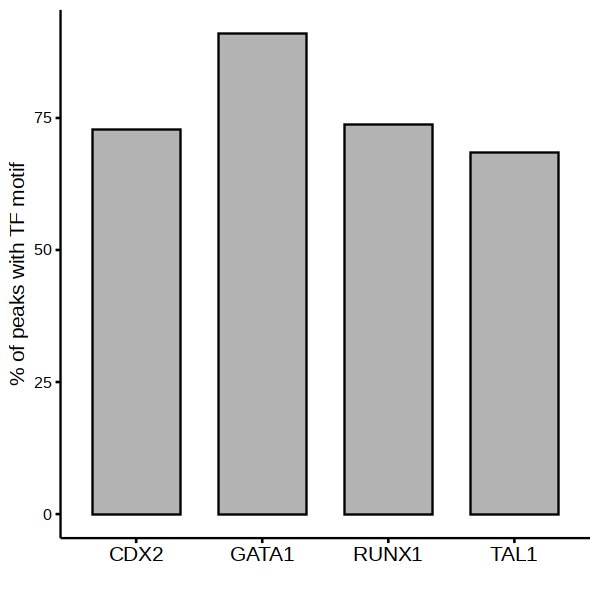

In [7]:
###############################
## Plot TF motif specificity ##
###############################

foo <- chip_peaks_with_motif.dt[,.N,by="tf"] %>% setnames("N","peaks_with_motif")
bar <- chip.dt[,.N,by="tf"] %>% setnames("N","total_peaks")

to.plot <- merge(foo,bar,by="tf") %>% 
  .[,percentage_peaks_motif:=peaks_with_motif/total_peaks*100]# %>%
  # melt(id.vars="tf",value.name="N")
options(repr.plot.width=5, repr.plot.height=5)
ggbarplot(to.plot, x="tf", y="percentage_peaks_motif", fill="gray70") +
  labs(x="", y="% of peaks with TF motif") +
  theme(
    axis.text.y = element_text(size=rel(0.75))
  )

In [8]:
head(chip_peaks_with_motif.dt)

chr,start,end,score,id,tf
<chr>,<int>,<int>,<int>,<chr>,<chr>
chr1,8283615,8283967,142,chr1:8283615-8283967,CDX2
chr1,12644572,12645084,362,chr1:12644572-12645084,GATA1
chr1,12644674,12644948,319,chr1:12644674-12644948,TAL1
chr1,12644729,12644901,115,chr1:12644729-12644901,RUNX1
chr1,12644730,12644881,114,chr1:12644730-12644881,CDX2
chr1,13154451,13154834,92,chr1:13154451-13154834,GATA1


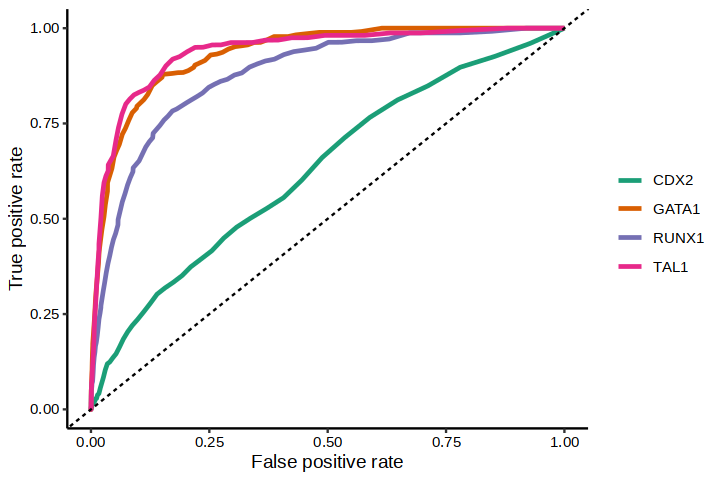

In [11]:
##############
## Plot ROC ##
#############

# Define range of binding scores
# seq.ranges <- seq(0,max(chip_insilico.dt$score)-0.05,by=0.01)
seq.ranges <- seq(0,1,by=0.01)
names(seq.ranges) <- as.character(1:length(seq.ranges))

# ov.dt <- foverlaps(chip_insilico.dt, chip.dt) %>% setnames("i.score","insilico_score")

roc.dt <- opts$TFs %>% map(function(i) {
  
  ov.dt <- foverlaps(chip_insilico.dt[tf==i], chip_peaks_with_motif.dt[tf==i]) %>% setnames("i.score","insilico_score")
  
  seq.ranges %>% map(function(j) {
    
    true_positives = sum(!is.na(ov.dt[insilico_score>=j,start]))
    false_negatives = sum(!is.na(ov.dt[insilico_score<=j,start]))
    false_positives = sum(is.na(ov.dt[insilico_score>=j,start]))
    true_negatives = sum(is.na(ov.dt[insilico_score<=j,start]))
    
    true_positive_rate = true_positives / (true_positives + false_negatives)
    false_positive_rate = false_positives / (false_positives+true_negatives)
    
    data.table(tf=i, min_score=j, tpr=true_positive_rate, fpr=false_positive_rate,
              TP = true_positives, FN = false_negatives, FP = false_positives, TN = true_negatives)
    
  }) %>% rbindlist
}) %>% rbindlist

options(repr.plot.width=6, repr.plot.height=4)
p <- ggplot(roc.dt, aes_string(x="fpr", y="tpr", color="tf")) +
  scale_color_brewer(palette="Dark2") +
  geom_line(size=1) +
  geom_abline(slope=1, intercept=0, linetype="dashed") +
  labs(x="False positive rate", y="True positive rate") +
  xlim(0,1) + ylim(0,1) +
  theme_classic() +
  theme(
    legend.title = element_blank(),
    axis.text = element_text(color="black")
  )
p

In [13]:
roc.dt[min_score==0.15]

tf,min_score,tpr,fpr,TP,FN,FP,TN
<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>
CDX2,0.15,0.4161491,0.2553642,134,188,4820,14055
TAL1,0.15,0.9562500,0.2747771,153,7,3205,8459
GATA1,0.15,0.9889868,0.5157186,449,5,7661,7194
RUNX1,0.15,0.9186992,0.3874432,226,20,10750,16996


In [10]:
pdf(file.path(io$outdir,"virtual_chip_roc_cuves.pdf"), width=8, height=5)
print(p)
dev.off()



png 
  2

### score

`geom_smooth()` using formula = 'y ~ x'


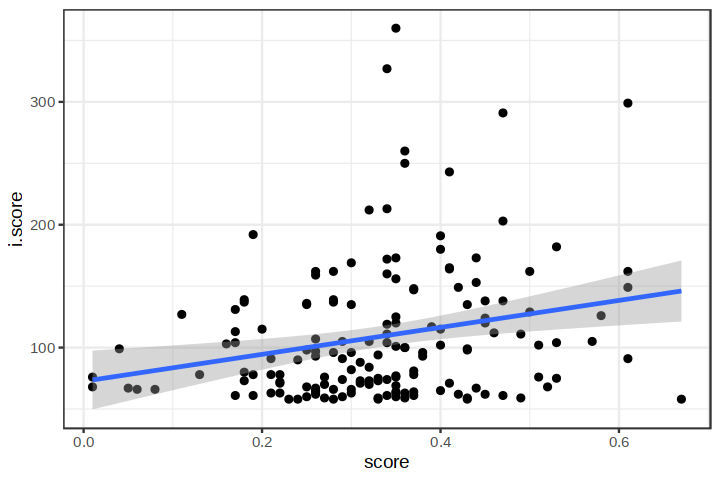

In [47]:
i = 'TAL1'
ov.dt <- foverlaps(chip_peaks_with_motif.dt[tf==i,], chip_insilico.dt[tf==i,]) #%>% setnames("score","insilico_score")
ggplot(ov.dt[!is.na(start)], aes(score, i.score)) + 
    geom_point() +
    geom_smooth(method='lm') + 
    theme_bw()

# Double bound peaks for TAL1 & GATA1

In [171]:
# Get more ChIP peaks to get higher overlap
chip.dt <- opts$TFs %>% map(function(i) {
 fread(args$chip_peaks.files[[i]], select=c(1,2,3,5)) %>%
  setnames(c("chr","start","end","score")) %>%
  .[,chr:=ifelse(grepl("chr",chr),chr,paste0("chr",chr))] %>%
  .[!chr%in%c("chrM","chrMT")] %>%
  .[,id:=sprintf("%s:%s-%s",chr,start,end)] %>%
  # .[score>=opts$min_chip_score] %>% 
  setorder(-score) %>% #head(n=10000) The overlap is so small that we can take all peaks instead
  .[,tf:=i] %>%
    return
}) %>% rbindlist %>% setkey(chr,start,end)

## Find ChIP-seq peaks that contain the TF motif 

opts$peak_extension <- 100

# i <- "TAL1"
chip_peaks_with_motif.dt <- opts$TFs %>% map(function(i) {
  
  gr <- makeGRangesFromDataFrame(chip.dt[tf==i], keep.extra.columns = T)
  
  motifmatcher.se <- motifmatchr::matchMotifs(
    pwms = pwms[i],
    subject = gr+opts$peak_extension,  
    genome = BSgenome.Mmusculus.UCSC.mm10, 
    out = "matches", 
    p.cutoff = 0.001, 
    w = 7
  ); rownames(motifmatcher.se) <- gr$id
  
  peaks.with.motif <- names(which(assay(motifmatcher.se)[,1]))
  return(chip.dt[tf==i & id%in%peaks.with.motif])
  
}) %>% rbindlist %>% setkey(chr,start,end)

In [172]:
# determine double pound peaks
args$extend_peaks = 100 # --> literally doesn't make difference unless going super wide
TAL1_chip = chip_peaks_with_motif.dt[tf=='TAL1'] %>%
    .[,`:=`(start=start-args$extend_peaks, end=end+args$extend_peaks)] %>%
    setkey(chr, start, end)
GATA1_chip = chip_peaks_with_motif.dt[tf=='GATA1']%>%
    .[,`:=`(start=start-args$extend_peaks, end=end+args$extend_peaks)] %>%
    setkey(chr, start, end)
RUNX1_chip = chip_peaks_with_motif.dt[tf=='RUNX1']%>%
    .[,`:=`(start=start-args$extend_peaks, end=end+args$extend_peaks)] %>%
    setkey(chr, start, end)

TAL1_GATA1 = foverlaps(TAL1_chip, GATA1_chip) %>% 
    .[!is.na(start)]%>%
    .[,`:=`(start=as.integer(start), end=as.integer(end))] %>%
    .[,c('chr', 'start', 'end', 'id')] %>% 
    setkey(chr, start, end)
nrow(TAL1_GATA1)

TAL1_RUNX1 = foverlaps(TAL1_chip, RUNX1_chip) %>% 
    .[!is.na(start)]%>%
    .[,`:=`(start=as.integer(start), end=as.integer(end))] %>%
    .[,c('chr', 'start', 'end', 'id')] %>% 
    setkey(chr, start, end)
nrow(TAL1_RUNX1)

GATA1_RUNX1 = foverlaps(GATA1_chip, RUNX1_chip) %>% 
    .[!is.na(start)]%>%
    .[,`:=`(start=as.integer(start), end=as.integer(end))] %>%
    .[,c('chr', 'start', 'end', 'id')] %>% 
    setkey(chr, start, end)
nrow(GATA1_RUNX1)

[1] 589

[1] 223

[1] 285

In [174]:
TAL1_GATA1_silico = merge(chip_insilico.dt[tf=='TAL1', c('chr', 'start', 'end', 'id', 'score')]%>% setnames('score', 'TAL1'), 
                      chip_insilico.dt[tf=='GATA1', c('id', 'score')] %>% setnames('score', 'GATA1'), 
                      by = 'id') %>%
    setkey(chr, start, end) 
nrow(TAL1_GATA1_silico)
TAL1_RUNX1_silico = merge(chip_insilico.dt[tf=='TAL1', c('chr', 'start', 'end', 'id', 'score')]%>% setnames('score', 'TAL1'), 
                      chip_insilico.dt[tf=='RUNX1', c('id', 'score')] %>% setnames('score', 'RUNX1'), 
                      by = 'id') %>%
    setkey(chr, start, end)
nrow(TAL1_RUNX1_silico)
GATA1_RUNX1_silico = merge(chip_insilico.dt[tf=='GATA1', c('chr', 'start', 'end', 'id', 'score')]%>% setnames('score', 'GATA1'), 
                      chip_insilico.dt[tf=='RUNX1', c('id', 'score')] %>% setnames('score', 'RUNX1'), 
                      by = 'id') %>%
    setkey(chr, start, end)
nrow(GATA1_RUNX1_silico)

[1] 2513

[1] 4529

[1] 5771

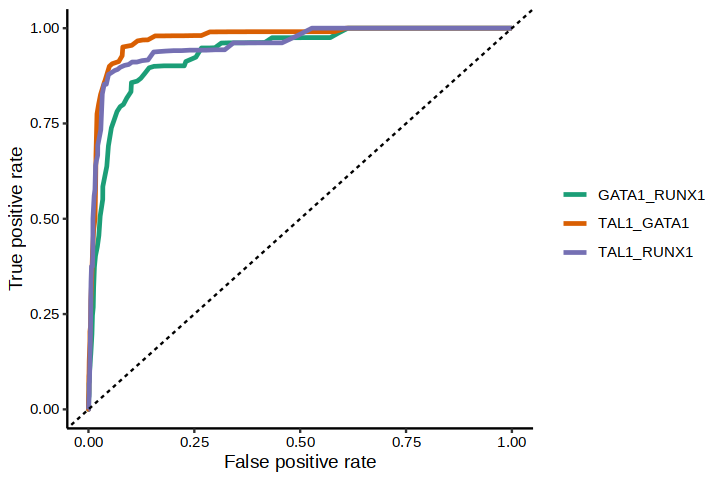

In [175]:
##############
## Plot ROC ##
#############

# Define range of binding scores
# seq.ranges <- seq(0,max(chip_insilico.dt$score)-0.05,by=0.01)
seq.ranges <- seq(0,1,by=0.01)
names(seq.ranges) <- as.character(1:length(seq.ranges))

# ov.dt <- foverlaps(chip_insilico.dt, chip.dt) %>% setnames("i.score","insilico_score")

  
  ov.dt <- foverlaps(TAL1_GATA1_silico, TAL1_GATA1)
TAL1_GATA1_ROC = seq.ranges %>% map(function(j) {
    
    true_positives = sum(!is.na(ov.dt[as.vector(ov.dt[,8])[[1]]>=j & as.vector(ov.dt[,9])[[1]]>=j,start]))
    false_negatives = sum(!is.na(ov.dt[as.vector(ov.dt[,8])[[1]]<=j & as.vector(ov.dt[,9])[[1]]<=j,start]))
    false_positives = sum(is.na(ov.dt[as.vector(ov.dt[,8])[[1]]>=j & as.vector(ov.dt[,9])[[1]]>=j,start]))
    true_negatives = sum(is.na(ov.dt[as.vector(ov.dt[,8])[[1]]<=j & as.vector(ov.dt[,9])[[1]]<=j,start]))
    
    true_positive_rate = true_positives / (true_positives + false_negatives)
    false_positive_rate = false_positives / (false_positives+true_negatives)
    
    data.table(tf=paste0(colnames(ov.dt[,c(8,9)]), collapse = '_'), min_score=j, tpr=true_positive_rate, fpr=false_positive_rate)
    
  }) %>% rbindlist

  ov.dt <- foverlaps(TAL1_RUNX1_silico, TAL1_RUNX1)

TAL1_RUNX1_ROC = seq.ranges %>% map(function(j) {
    
    true_positives = sum(!is.na(ov.dt[as.vector(ov.dt[,8])[[1]]>=j & as.vector(ov.dt[,9])[[1]]>=j,start]))
    false_negatives = sum(!is.na(ov.dt[as.vector(ov.dt[,8])[[1]]<=j & as.vector(ov.dt[,9])[[1]]<=j,start]))
    false_positives = sum(is.na(ov.dt[as.vector(ov.dt[,8])[[1]]>=j & as.vector(ov.dt[,9])[[1]]>=j,start]))
    true_negatives = sum(is.na(ov.dt[as.vector(ov.dt[,8])[[1]]<=j & as.vector(ov.dt[,9])[[1]]<=j,start]))
    
    true_positive_rate = true_positives / (true_positives + false_negatives)
    false_positive_rate = false_positives / (false_positives+true_negatives)
    
    data.table(tf=paste0(colnames(ov.dt[,c(8,9)]), collapse = '_'), min_score=j, tpr=true_positive_rate, fpr=false_positive_rate)
    
  }) %>% rbindlist

  ov.dt <- foverlaps(GATA1_RUNX1_silico, GATA1_RUNX1)

GATA1_RUNX1_ROC = seq.ranges %>% map(function(j) {
    
    true_positives = sum(!is.na(ov.dt[as.vector(ov.dt[,8])[[1]]>=j & as.vector(ov.dt[,9])[[1]]>=j,start]))
    false_negatives = sum(!is.na(ov.dt[as.vector(ov.dt[,8])[[1]]<=j & as.vector(ov.dt[,9])[[1]]<=j,start]))
    false_positives = sum(is.na(ov.dt[as.vector(ov.dt[,8])[[1]]>=j & as.vector(ov.dt[,9])[[1]]>=j,start]))
    true_negatives = sum(is.na(ov.dt[as.vector(ov.dt[,8])[[1]]<=j & as.vector(ov.dt[,9])[[1]]<=j,start]))
    
    true_positive_rate = true_positives / (true_positives + false_negatives)
    false_positive_rate = false_positives / (false_positives+true_negatives)
    
    data.table(tf=paste0(colnames(ov.dt[,c(8,9)]), collapse = '_'), min_score=j, tpr=true_positive_rate, fpr=false_positive_rate)
    
  }) %>% rbindlist

roc.dt = rbindlist(list(TAL1_GATA1_ROC, TAL1_RUNX1_ROC, GATA1_RUNX1_ROC))

options(repr.plot.width=6, repr.plot.height=4)
p <- ggplot(roc.dt, aes_string(x="fpr", y="tpr", color="tf")) +
  scale_color_brewer(palette="Dark2", name='Tal1-Gata1 double bound') +
  geom_line(size=1) +
  geom_abline(slope=1, intercept=0, linetype="dashed") +
  labs(x="False positive rate", y="True positive rate") +
  xlim(0,1) + ylim(0,1) +
  theme_classic() +
  theme(
    legend.title = element_blank(),
    axis.text = element_text(color="black")
  )
p